### 馬達論文研究
### 第三步 遷移式學習
### 馬達B 11000RPM
### CNN_VGG
### 雙階段泛化

In [1]:
# 匯入所需函式庫
import os
import logging
import absl.logging
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder, RobustScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate, Add, Activation, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from gpu_utils import device_scope
warnings.filterwarnings("ignore")

In [2]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'T2\\11000rpm\\{screws}\\T2_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [3]:
# 加載資料
rootDir = os.getcwd()
modelDirectory = f'{rootDir}\\階段2\\model'
myfeatureDirectory = f'{rootDir}\\階段2\\myfeature'

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T2 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [4]:
# 合併資料
combined_data = pd.concat(datasets_T2, ignore_index=True)

In [5]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [6]:
# 標籤編碼
le_screws = LabelEncoder()
combined_data['screws'] = le_screws.fit_transform(combined_data['screws'])

In [7]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

自訂 Label Mapping:
8screws: 0
1screws: 1
2screws: 2
3screws: 3
4screws: 4


In [8]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [9]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42
)

In [10]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# 載入模型
model_path = f'{modelDirectory}\\VGG16_B8000.keras'

# 載入模型
model = load_model(model_path)

# 確認模型載入成功
print("模型已成功載入。")

模型已成功載入。


In [12]:
# 計算需要凍結的層數（保留 50% 可訓練）
num_layers = len(model.layers)
train_layers_2 = int(num_layers * 0.5)  # 50% 可訓練
freeze_layers_2 = num_layers - train_layers_2  # 50% 凍結

# 凍結前 freeze_layers_2 層
for layer in model.layers[:freeze_layers_2]:
    layer.trainable = False

# 確認層狀態
for i, layer in enumerate(model.layers):
    print(f"Model 3 - Layer {i}: {layer.name} | Trainable: {layer.trainable}")

Model 3 - Layer 0: input_layer | Trainable: False
Model 3 - Layer 1: conv1d | Trainable: False
Model 3 - Layer 2: conv1d_1 | Trainable: False
Model 3 - Layer 3: max_pooling1d | Trainable: False
Model 3 - Layer 4: conv1d_2 | Trainable: False
Model 3 - Layer 5: conv1d_3 | Trainable: False
Model 3 - Layer 6: max_pooling1d_1 | Trainable: False
Model 3 - Layer 7: conv1d_4 | Trainable: False
Model 3 - Layer 8: conv1d_5 | Trainable: False
Model 3 - Layer 9: conv1d_6 | Trainable: False
Model 3 - Layer 10: max_pooling1d_2 | Trainable: False
Model 3 - Layer 11: conv1d_7 | Trainable: False
Model 3 - Layer 12: conv1d_8 | Trainable: False
Model 3 - Layer 13: conv1d_9 | Trainable: True
Model 3 - Layer 14: max_pooling1d_3 | Trainable: True
Model 3 - Layer 15: conv1d_10 | Trainable: True
Model 3 - Layer 16: conv1d_11 | Trainable: True
Model 3 - Layer 17: conv1d_12 | Trainable: True
Model 3 - Layer 18: max_pooling1d_4 | Trainable: True
Model 3 - Layer 19: flatten | Trainable: True
Model 3 - Layer 20: d

In [13]:
# 重新訓練模型
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=["sparse_categorical_crossentropy"],
    metrics=["accuracy"]
)

In [14]:
# 訓練模型
history = model.fit(
    X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
    y_train_screws,
    validation_data=(
        X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
        y_test_screws
    ),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.3294 - loss: 4.6932 - val_accuracy: 0.7379 - val_loss: 0.8358
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6006 - loss: 1.0582 - val_accuracy: 0.8414 - val_loss: 0.5479
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7385 - loss: 0.7295 - val_accuracy: 0.8831 - val_loss: 0.3810
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7932 - loss: 0.5606 - val_accuracy: 0.9115 - val_loss: 0.3046
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8347 - loss: 0.4611 - val_accuracy: 0.9399 - val_loss: 0.2338
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8844 - loss: 0.3625 - val_accuracy: 0.9499 - val_loss: 0.1889
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9038 - loss: 0.3003 - val_accuracy: 0.9549 - val_loss: 0.1542
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9099 - loss: 0.2644 - val_accuracy: 0.9616 -

In [15]:
# 清除
tf.keras.backend.clear_session()

In [16]:
# 模型架構
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 105, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 52, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 52, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 52, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Screw_Number_Output (Dense)     │ (None, 5)              │           32

 Total params: 94,289 (368.32 KB)

 Trainable params: 23,109 (90.27 KB)

 Non-trainable params: 24,960 (97.50 KB)

 Optimizer params: 46,220 (180.55 KB)

In [17]:
# 評估模型
results = model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0021
Loss: 0.0011, Accuracy: 1.0000


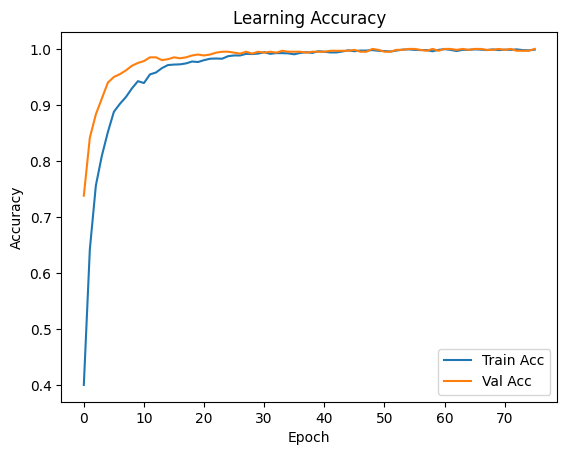

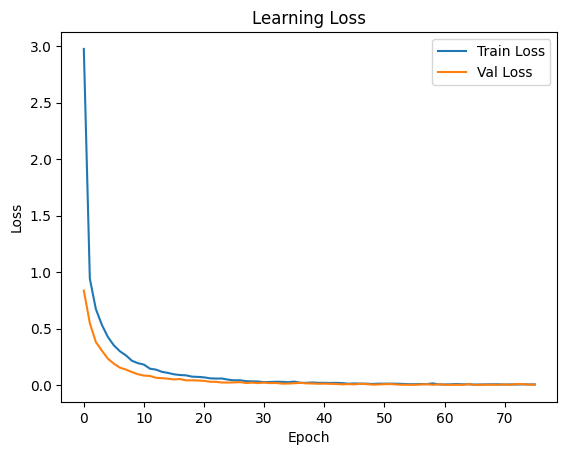

In [18]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


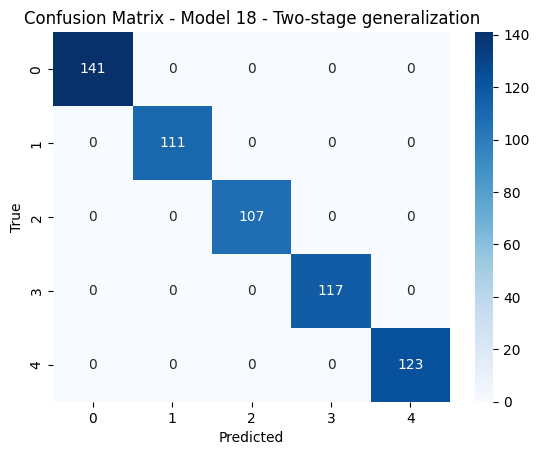

In [19]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    numeric_labels = range(len(label_encoder.classes_))  # 使用數字標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=numeric_labels, yticklabels=numeric_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, le_screws, "Confusion Matrix - Model 18 - Two-stage generalization")

In [20]:
# 儲存模型
model.save(f'{rootDir}\\階段2\\model\\VGG16_B11000.keras')